### Usaremos la tecnica LLM as a Judge para evaluar nuestro modelo entrenado despues de hacer el fine tuning de llama 3.2. El LLM que sera nuestro juez es chat GPT 4.o Mini 

In [15]:
#Importar librerias necesarias 
import os
import sys
current_dir = os.getcwd()
src_dir = os.path.join(current_dir, '../')
sys.path.append(src_dir)
# Importa helpers
from tools.helpers import GPT4o_mini, save_to_json, load_text_file, GPT4o
from data.tokenizer import TokenizadorLlamadas
from models.inference import inference
import torch
from transformers import AutoModelForCausalLM
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from langchain.evaluation import load_evaluator
from langchain_huggingface import HuggingFaceEmbeddings

### Definir el prompt template que se usara para el Juez

In [16]:
prompt_template = """
Eres un experto evaluador de un modelo de lenguaje de instrucción que responde a preguntas de un cliente de un concesionario que desea adquirir un vehiculo.
Tu tarea es analizar la relevancia de la respuesta generada comparada con la respuesta original entregada.
Basado en la relevancia y la similitud de la respuesta generada con la respuesta original, deberas clasificarlas como
"NO_RELEVANTE", "PARCIALMENTE_RELEVANTE", o "RELEVANTE".

Aqui esta la data para la evaluación:

Pregunta: {question}
Respuesta Original: {real_answer}
Respuesta Generada: {llm_answer}

Por favor analiza el contenido y el contexto de la respuesta generada en relacion con la respuesta original
responde y entrega tu evaluacion en un parsable JSON sin usar code blocks:

{{
  "Relevancia": "NO_RELEVANTE" | "PARCIALMENTE_RELEVANTE" | "RELEVANTE",
  "Explicacion": "[Entrega una breve explicacion para tu evaluación]"
}}
""".strip()

### Cargar el set de datos de preguntas respuesta que se usara como conjunto de validacion 

In [17]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"
max_length=2048
judith_tokenizer = TokenizadorLlamadas(max_length,model_name)
tokenized_dataset=judith_tokenizer.tokenize_and_split_data('../data/data.json')
val_dataset = tokenized_dataset["test"]

### Cargar modelo con el mejor resultado despues del finetuning, este modelo es el que en el entrenamiento tuvo menor loss

In [18]:
finetuned_model_name = '../../../../judith_llama3.2_1b_15epoch1_bSizeAdamW/final'
max_length=2048
max_output=1000

device_count = torch.cuda.device_count()
if device_count > 0:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

finetuned_model = AutoModelForCausalLM.from_pretrained(finetuned_model_name, local_files_only=True)
finetuned_model.to(device) 

test_question = "donde se encuentran ubicados?"
finetuned_model_answer=inference(test_question, finetuned_model, judith_tokenizer.tokenizer,max_input_tokens=max_length, max_output_tokens=max_output)
print(finetuned_model_answer)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  
 Estamos acá en San Fernando, California. No sé qué día nos podría visitar.  



### Generar respues de nuestro modelo Llama 3.2 fine tuneado para cada una de las preguntas en el set de datos de validacion 

In [7]:
respuestas_modeloLLM=[]

for pregunta_respuesta in val_dataset:
    question=pregunta_respuesta['question']
    real_answer=pregunta_respuesta['answer']
    llm_answer=inference(question, finetuned_model, judith_tokenizer.tokenizer,max_input_tokens=max_length, max_output_tokens=max_output)
    respuestas_modeloLLM.append({'question':question,'real_answer':real_answer,'llm_answer':llm_answer})
save_to_json(respuestas_modeloLLM,'respuestas_llm.json')


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


La celda anterior genera un archivo .json con el resultado de las respuestas generadas por el modelo

In [19]:
#Cargamos las respuestas desde el json 
with open('respuestas_llm_depurado.json', 'r', encoding='utf-8') as archivo:
    respuestas_modeloLLM = json.load(archivo)  # Carga el contenido como un diccionario

### Iteramos por cada una de las respuestas generadas y las pasamos al Juez GPT 4o Mini usando el prompt definido anterirmente, el resultado se almaceno en un archivo .json junto con el resultado de la distancia de coseno entre las respuestas

In [20]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}
hf = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

hf_evaluator = load_evaluator("pairwise_embedding_distance", embeddings=hf)

In [22]:
judge_veredict_list=[]
for resp_modeloLLM in respuestas_modeloLLM:
    if resp_modeloLLM["question"].strip() != '' and resp_modeloLLM["real_answer"].strip() != '':  
        prompt_for_judge=prompt_template.format(**resp_modeloLLM)
        judge_veredict=GPT4o_mini(prompt_for_judge)
        #similitud de coseno
        sim = hf_evaluator.evaluate_string_pairs(prediction=resp_modeloLLM['llm_answer'],prediction_b=resp_modeloLLM['real_answer'])
        judge_veredict_list.append(resp_modeloLLM | json.loads(judge_veredict) | {'hf_similarity': sim['score']})
save_to_json(judge_veredict_list,'judge_veredict_list_gpt4o_mini_1.json')

In [4]:
#Cargamos las respuestas de chat GPT 4o Mini desde el json
with open('judge_veredict_list_gpt4o_mini.json', 'r', encoding='utf-8') as archivo:
    judge_veredict_list = json.load(archivo)  # Carga el contenido como un diccionario

In [6]:
judge_veredict_df = pd.DataFrame(judge_veredict_list)

### Analisis de la relevancia

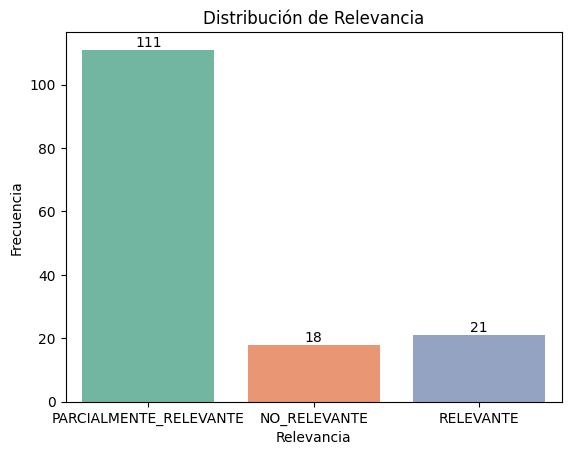

In [7]:
# Crear el gráfico de barras
sns.countplot(data=judge_veredict_df, x='Relevancia', hue='Relevancia', palette='Set2', dodge=False, legend=False)
plt.xlabel('Relevancia')
plt.ylabel('Frecuencia')
plt.title('Distribución de Relevancia')

# Agregar los valores encima de cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', 
                       fontsize=10, color='black')

plt.show()

In [5]:
judge_veredict_df.head()

,question,real_answer,llm_answer,Relevancia,Explicacion,hf_similarity
0,"Disculpe, ¿de qué es? ¿Me dijo? \n","Del dealer de autos, de los vehículos. \n",Le saludo de acá del dealer. Nos comunicamos ...,PARCIALMENTE_RELEVANTE,La respuesta generada menciona el dealer y el ...,0.331527
1,Y pues como yo ya había visto opciones y me h...,"Ok, perfecto. En este caso no hay problema. N...","Ok, perfecto. Entonces no hay problema. Le vo...",PARCIALMENTE_RELEVANTE,La respuesta generada mantiene un tono similar...,0.143104
2,"Mira que estoy interesado, pero estoy ocupado...",Por un carro sedan mínimo 1800 de enganche. \n,"Ok, fíjese que nosotros por el momento no man...",PARCIALMENTE_RELEVANTE,La respuesta generada menciona una cantidad de...,0.364067
3,"Estoy buscando un carrito pequeño, no importa...",¿Es su primera vez financiando?\n,Perfecto. ¿Sería su primera vez financiando? ...,PARCIALMENTE_RELEVANTE,La respuesta generada hace una pregunta relaci...,0.234944
4,Solo en la Curacao. Recién tengo un crédito d...,Excelente. ¿Está buscando algún tipo de vehíc...,"¿Busca algún vehículo en especial, marca, año...",PARCIALMENTE_RELEVANTE,La respuesta generada pregunta sobre el tipo d...,0.354767


### Analisis de la similitud del coseno

In [6]:
judge_veredict_df['hf_similarity'].describe()

count    150.000000
mean       0.416472
std        0.161746
min        0.030495
25%        0.298667
50%        0.444426
75%        0.521437
max        0.893888
Name: hf_similarity, dtype: float64

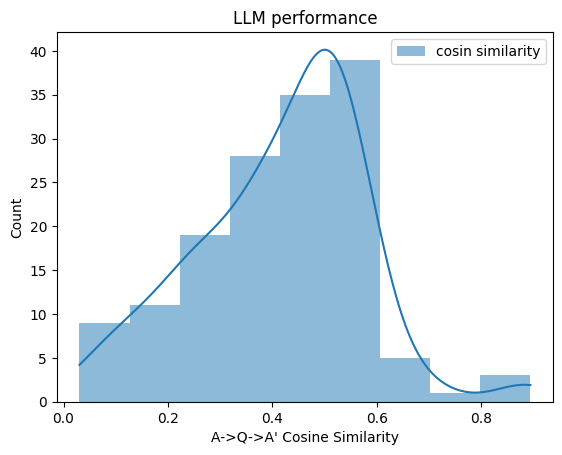

In [7]:
# Ajustar el ancho de las barras y eliminar los bordes
sns.histplot(judge_veredict_df['hf_similarity'], kde=True, label='cosin similarity', binwidth=0.1, edgecolor=None)

plt.title("LLM performance")
plt.xlabel("A->Q->A' Cosine Similarity")
plt.legend()
plt.show()

In [11]:
filtered_df = judge_veredict_df[judge_veredict_df['hf_similarity'] > .5]
# Contar el total de filas que quedaron
num_filas = filtered_df.shape[0]

print("Total de respuestas con similitud de coseno mayor que 0.4:", num_filas)

Total de respuestas con similitud de coseno mayor que 0.4: 52
